# Practical 4 — Text Classification: Sentiment Analysis
### A full pipeline on real tweets

For three weeks we turned text into numbers (BoW, TF-IDF, embeddings). Today
those numbers finally *do* something — we build a complete pipeline that reads
a tweet and predicts its sentiment: negative, neutral, or positive.

**This pipeline isn't just for sentiment.** The exact same structure —
preprocess → vectorize → train a classifier → evaluate — is how you'd build a
spam filter, a support-ticket router, a topic tagger, a language detector, or
any text classification task. Only the labels change. Learn it once here, reuse
it everywhere.

**Today's data:** `tweet_eval` — real tweets, human-labelled for sentiment.
Tweets are short, messy, sarcastic, and full of context — which makes this
genuinely *hard*. You'll see the model work well, then fail in interesting,
predictable ways. Those failures are the whole point: they're what motivates
the smarter models coming in later weeks.

**By the end you'll be able to:**
- Load a real dataset from Hugging Face
- Build a full preprocess → vectorize → classify → evaluate pipeline
- Read precision, recall, F1, and a confusion matrix correctly
- Spot *where* and *why* a word-counting model fails

https://huggingface.co/datasets/cardiffnlp/tweet_eval

In [ ]:
# 1. SETUP
!pip install -q datasets scikit-learn nltk

import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# 2. LOAD DATA — from Hugging Face
from datasets import load_dataset

data = load_dataset("cardiffnlp/tweet_eval", "sentiment")

# labels: 0 = negative, 1 = neutral, 2 = positive
label_names = {0: "negative", 1: "neutral", 2: "positive"}

train_df = data["train"].to_pandas()
test_df  = data["test"].to_pandas()

train_df["sentiment"] = train_df["label"].map(label_names)
test_df["sentiment"]  = test_df["label"].map(label_names)

print("Train:", train_df.shape, " Test:", test_df.shape)
train_df[["text", "sentiment"]].head(10)

README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.78MB            

sentiment/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sentiment/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  901kB            

sentiment/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train: (45615, 3)  Test: (12284, 3)


,text,sentiment
0,"""QT @user In the original draft of the 7th boo...",positive
1,"""Ben Smith / Smith (concussion) remains out of...",neutral
2,Sorry bout the stream last night I crashed out...,neutral
3,Chase Headley's RBI double in the 8th inning o...,neutral
4,@user Alciato: Bee will invest 150 million in ...,positive
5,@user LIT MY MUM 'Kerry the louboutins I wonde...,positive
6,"""\"""""""" SOUL TRAIN\"""""""" OCT 27 HALLOWEEN SPECIA...",positive
7,So disappointed in wwe summerslam! I want to s...,negative
8,"""This is the last Sunday w/o football .....,NF...",positive
9,@user @user CENA & AJ sitting in a tree K-I-S-...,neutral


### 📝 Observe
- Look at the structure printed above — how many reviews are in the train split?
In the test split? Why do we need the splitting?

- Read the first few tweets and their labels. Notice how short they are compared
to a movie review — and how much meaning is packed into few words, with
@mentions, hashtags, and emojis mixed in.

sentiment
neutral     20673
positive    17849
negative     7093
Name: count, dtype: int64


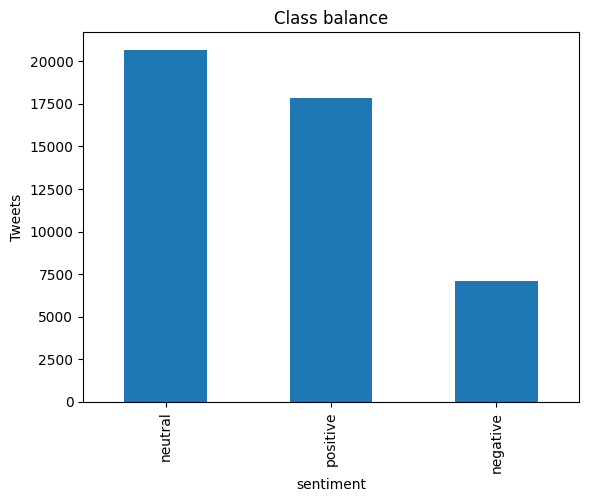

In [ ]:
# 3. EXPLORE — just the essentials

# 3a. Class balance
print(train_df["sentiment"].value_counts())
train_df["sentiment"].value_counts().plot(kind="bar", title="Class balance")
plt.ylabel("Tweets")
plt.show()

### 📝 Discuss
1. Is this balanced or imbalanced? Which class is largest?
2. If a lazy model always guessed the biggest class, what accuracy would it
   get? Write your guess — we'll compare the real model to it later. This
   "always guess majority" number is your true baseline, not 0%.

In [ ]:
# 3b. Top words per class — a peek at what the model will learn
from collections import Counter
stop_words = set(stopwords.words('english'))

def top_words(texts, n=12):
    words = " ".join(texts).lower().split()
    words = [w for w in words if w.isalpha() and w not in stop_words and len(w) > 2]
    return Counter(words).most_common(n)

for cls in ["negative", "neutral", "positive"]:
    print(f"\nTop words — {cls.upper()}:")
    print([w for w, c in top_words(train_df[train_df.sentiment == cls]["text"])])


Top words — NEGATIVE:
['may', 'tomorrow', 'like', 'going', 'get', 'day', 'see', 'still', 'want', 'one', 'time', 'think']

Top words — NEUTRAL:
['may', 'tomorrow', 'going', 'day', 'get', 'like', 'see', 'night', 'new', 'friday', 'sunday', 'time']

Top words — POSITIVE:
['may', 'tomorrow', 'see', 'day', 'going', 'night', 'good', 'get', 'like', 'love', 'friday', 'time']


### 📝 Observe
1. Do the negative, positive and neutral word lists look different, as you'd expect?

In [ ]:
all_text = pd.concat([train_df['text'], test_df['text']])
raw_words = " ".join(all_text).split()
unique_words_raw = len(set(raw_words))

print(f"Total unique words in raw dataframe (before preprocessing): {unique_words_raw}")

Total unique words in raw dataframe (before preprocessing): 130675


## 4. Preprocessing

Clean each tweet into a consistent form. Tweets need a bit more care than plain
text — @mentions, links, and symbols.

In [ ]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)     # remove links
    text = re.sub(r'@\w+', '', text)        # remove @mentions
    text = re.sub(r'[^a-z\s]', ' ', text)   # keep only letters
    tokens = [t for t in text.split() if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

n = 7

# See it on one tweet
print("BEFORE:", train_df["text"].iloc[n])
print("AFTER: ", preprocess(train_df["text"].iloc[n]))

BEFORE: So disappointed in wwe summerslam! I want to see john cena wins his 16th title
AFTER:  disappointed wwe summerslam want see john cena wins title


### 🔬 Experiment
Change the `n` above to a few other numbers and watch what cleaning does
to different tweets. Find one where preprocessing **removes something that
mattered** (a hashtag with meaning, an emoji-driven tone, a "not"). Note it —
we'll see the consequences.

In [ ]:
# Apply to both sets
train_df["clean"] = train_df["text"].apply(preprocess)
test_df["clean"]  = test_df["text"].apply(preprocess)

In [ ]:
all_text = pd.concat([train_df['clean'], test_df['clean']])
raw_words = " ".join(all_text).split()
unique_words = len(set(raw_words))

print(f"Total unique words in raw dataframe (after preprocessing): {unique_words}")
print(f"Reduction in vocab size -> {(unique_words_raw - unique_words)/unique_words_raw*100} %")

Total unique words in raw dataframe (after preprocessing): 47671
Reduction in vocab size -> 63.51941840443849 %


## 5. Vectorize + Train

Turn cleaned tweets into TF-IDF vectors (Practical 2), then train a Logistic
Regression classifier — a fast, strong baseline for text.

**The one rule:** fit the vectorizer on **train only**, then just *transform*
test. The test set stays unseen.

In [ ]:
import time

start = time.time()
vectorizer = TfidfVectorizer() # max_features=5000
X_train = vectorizer.fit_transform(train_df["clean"])   # FIT on train
X_test  = vectorizer.transform(test_df["clean"])        # TRANSFORM test only

y_train = train_df["sentiment"]
y_test  = test_df["sentiment"]

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
end = time.time()
print(f"Trained in {end-start} seconds")

predictions = model.predict(X_test)
print("Done. Sample predictions:", list(predictions[:8]))

Trained in 30.425649166107178 seconds
Done. Sample predictions: ['negative', 'neutral', 'neutral', 'positive', 'neutral', 'neutral', 'neutral', 'neutral']


### 📝 Discuss

1. What does `fit` actually learn? (What is the vectorizer building when it
   sees the training text?)
2. What would go wrong if we called `fit_transform` on the test set too?
   Why is that considered a bug — a form of "data leakage" — and not just a
   style choice? Be ready to explain this out loud.

### 🔬 Experiment
Try putting max_feature parameter in the tfidfvectorizer - what happens to the training speed? What will be the repercussions?

## 6. Evaluate — Properly

One accuracy number hides too much. Look at per-class precision, recall, F1,
and the confusion matrix.

In [ ]:
from sklearn.metrics import accuracy_score
print(f"Accuracy: {accuracy_score(y_test, predictions):.3f}\n")
print(classification_report(y_test, predictions))

Accuracy: 0.582

              precision    recall  f1-score   support

    negative       0.69      0.32      0.44      3972
     neutral       0.58      0.77      0.66      5937
    positive       0.51      0.56      0.54      2375

    accuracy                           0.58     12284
   macro avg       0.60      0.55      0.54     12284
weighted avg       0.60      0.58      0.56     12284



### 📝 Discuss
1. Compare accuracy to your "always guess majority" baseline from Section 3.
   How much better is the real model? That *gap* is what it actually learned.
2. Look at the **per-class F1 scores**. Which class does the model handle
   worst?

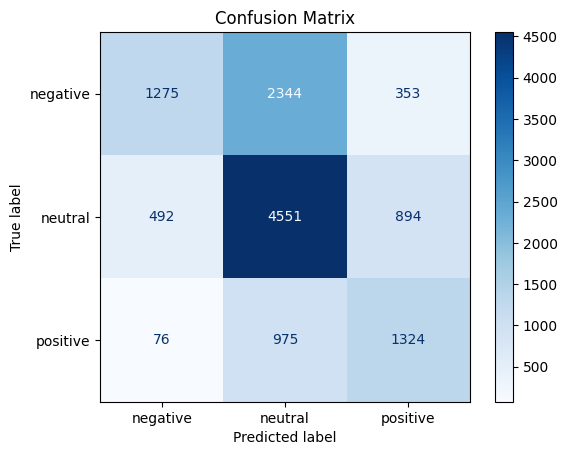

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, predictions, labels=model.classes_)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

### 📝 Observe
In the confusion matrix, find the biggest off-diagonal number — the model's
most common mistake. Is it confusing neutral with positive? Neutral with
negative? Does that pattern make intuitive sense for how people actually tweet?

## 7. Where Does It Fail? — the most important cell

A model's mistakes tell you more than its successes. Let's read some tweets the
model got wrong.

In [ ]:
test_df = test_df.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
wrong = test_df[predictions != y_test_reset]

print(f"Got {len(wrong)} of {len(test_df)} wrong.\n")
for _, row in wrong.head(8).iterrows():
    pred = model.predict(vectorizer.transform([row["clean"]]))[0]
    print(f"TRUE: {row['sentiment']:8s} | PREDICTED: {pred:8s}")
    print(f"  {row['text']}")
    print("-" * 70)

Got 5134 of 12284 wrong.

TRUE: neutral  | PREDICTED: negative
  @user @user what do these '1/2 naked pics' have to do with anything? They're not even like that.
----------------------------------------------------------------------
TRUE: negative | PREDICTED: neutral 
  @user Wow,first Hugo Chavez and now Fidel Castro. Danny Glover, Michael Moore, Oliver Stone, and Sean Penn are running out of heroes.
----------------------------------------------------------------------
TRUE: positive | PREDICTED: neutral 
  Twitter's #ThankYouObama Shows Heartfelt Gratitude To POTUS
----------------------------------------------------------------------
TRUE: neutral  | PREDICTED: positive
  An interesting security vulnerability - albeit not for the everyday car thief
----------------------------------------------------------------------
TRUE: negative | PREDICTED: neutral 
  When Ryan privatizes SS, Medicare, Medicaid, & does away with ACA, what will Trump's base feel about "change" then? That's a b

In [ ]:
# 7b. A peculiar direct comparison — run these hand-picked tweets
peculiar = [
    "this is bad",
    "this is not bad",
    "this is not bad at all",
    "oh great another monday",
    "great game absolutely loved it",
    "the movie was okay nothing special",
    "food was amazing but service was terrible",
    "Food was terrific!",
    "Great! i am lost my money"
]

for t in peculiar:
    pred = model.predict(vectorizer.transform([preprocess(t)]))[0]
    print(f"{pred:9s} <- {t}")

negative  <- this is bad
negative  <- this is not bad
negative  <- this is not bad at all
positive  <- oh great another monday
positive  <- great game absolutely loved it
neutral   <- the movie was okay nothing special
positive  <- food was amazing but service was terrible
neutral   <- Food was terrific!
positive  <- Great! i am lost my money


### 📝 Discuss
Read those misclassified tweets carefully. You'll likely spot patterns:

- **Negation:** "not bad at all" — the model sees "bad" and predicts negative,
  missing that "not" flips it.
- **Sarcasm/irony:** "oh great, another delay 🙄" — sees "great," predicts
  positive, completely fooled.
- **Mixed sentiment:** "food was amazing but service was terrible" — both
  signals present, the model can only pick one.
- **Context/world-knowledge:** tweets that need to know *what* is being
  discussed to judge tone.

**The big question:** these aren't random errors — they're a *category* of
failure. What do they all have in common? (The model counts words; it doesn't
understand meaning, order, or context.) Which of these would a model that
understood word *meaning* and *context* fix?

## 8. Challenge — Push the Score Up

Your baseline works. Try to raise the **macro-F1** (macro = average across all
three classes, so improving the weak neutral class actually counts).

In [ ]:
# Copy this block and experiment. Change ONE thing at a time so you know what helped.
start = time.time()
vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))   # try (1, 2) for bigrams
X_train = vectorizer.fit_transform(train_df["clean"])
X_test  = vectorizer.transform(test_df["clean"])

model = LogisticRegression(max_iter=1000)   # try class_weight="balanced"
model.fit(X_train, y_train)
end = time.time()
print(f"Trained in {end-start} seconds")

print(classification_report(y_test, model.predict(X_test)))

Trained in 14.135800838470459 seconds
              precision    recall  f1-score   support

    negative       0.68      0.35      0.46      3972
     neutral       0.59      0.74      0.66      5937
    positive       0.50      0.58      0.54      2375

    accuracy                           0.59     12284
   macro avg       0.59      0.56      0.55     12284
weighted avg       0.60      0.59      0.57     12284



### 🔬 Experiments to try
Change one thing at a time and watch the macro-F1:

1. **Bigrams:** `ngram_range=(1, 2)`. Does catching word *pairs* like "not bad"
   help?
2. **Vocabulary size:** try `max_features=2000`, then `10000`. More always
   better? Or does it plateau?
3. **Different model:** swap `LogisticRegression`

**Did any change actually fix
the "not bad" problem?**

## 10. The Embedding Way — Word Vectors Instead of Word Counts

Last practical (Word Embeddings) you saw that GloVe places words with similar
*meaning* near each other — "good" and "great" are neighbours, even though
TF-IDF treats them as unrelated columns.

Now we use that. Instead of TF-IDF counts, we represent each tweet by the
**average of its GloVe word vectors** — a simple, classic way to turn word
embeddings into one document vector. Same task, same classifier, just meaning-
aware numbers underneath.

In [ ]:
# Load pretrained GloVe vectors via gensim (25-dim Twitter GloVe — small & fast,
# and trained ON tweets, so it fits our data well)
!pip install gensim
import gensim.downloader as api

print("Downloading GloVe (Twitter, 25d)... one-time, ~100MB")
glove = api.load("glove-twitter-25")
print("Loaded. Vocabulary size:", len(glove.index_to_key))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 13.3 MB/s eta 0:00:00
[==================================================] 100.0% 104.8/104.8MB downloaded
Loaded. Vocabulary size: 1193514


In [ ]:
# Turn each tweet into ONE vector by averaging its word vectors
def tweet_to_vector(text, model, dim=25):
    words = preprocess(text).split()
    vectors = [model[w] for w in words if w in model]
    if len(vectors) == 0:
        return np.zeros(dim)          # tweet had no known words, now correctly matches dim=25
    return np.mean(vectors, axis=0)   # average = the tweet's "meaning" vector

# Build embedding matrices (fast — just lookups and averaging)
X_train_emb = np.vstack([tweet_to_vector(t, glove) for t in train_df["text"]])
X_test_emb  = np.vstack([tweet_to_vector(t, glove) for t in test_df["text"]])

print("Embedding matrix shape:", X_train_emb.shape)  # Should be (n_tweets, 25)

Embedding matrix shape: (45615, 25)


### 📝 Discuss
Look at that shape — every tweet is now just **25 numbers**, no matter how long
it was. Compare to TF-IDF, where each tweet was a 5000-long mostly-zero vector.

1. Which representation is more compact?
2. TF-IDF's 5000 dimensions were *interpretable* (one per word). These 25 are
   not — no single number means "contains the word good." What did we trade
   away, and what did we gain?

In [ ]:
# Same classifier, same evaluation — only the vectors changed
emb_model = LogisticRegression(max_iter=1000)
emb_model.fit(X_train_emb, train_df["sentiment"])

emb_predictions = emb_model.predict(X_test_emb)
print("GloVe-embedding pipeline:")
print(classification_report(y_test, emb_predictions))

GloVe-embedding pipeline:
              precision    recall  f1-score   support

    negative       0.65      0.45      0.53      3972
     neutral       0.58      0.77      0.66      5937
    positive       0.59      0.42      0.49      2375

    accuracy                           0.60     12284
   macro avg       0.61      0.54      0.56     12284
weighted avg       0.61      0.60      0.59     12284



### Switching to Word2Vec (Google News 300d)
Now we use the larger Word2Vec model. Note that this model was trained on news articles, not tweets, so it might handle formal language better but could miss some Twitter-specific slang.

In [ ]:
print("Downloading Word2Vec (Google News, 300d)... ~1.6GB")
w2v = api.load("word2vec-google-news-300")
print("Loaded. Vocabulary size:", len(w2v.index_to_key))

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Loaded. Vocabulary size: 3000000


In [ ]:
# Re-run embedding with 300 dimensions
def tweet_to_vector_w2v(text, model, dim=300):
    words = preprocess(text).split()
    vectors = [model[w] for w in words if w in model]
    if len(vectors) == 0:
        return np.zeros(dim)
    return np.sum(vectors, axis=0)

X_train_w2v = np.vstack([tweet_to_vector_w2v(t, w2v) for t in train_df["text"]])
X_test_w2v  = np.vstack([tweet_to_vector_w2v(t, w2v) for t in test_df["text"]])

print("Word2Vec matrix shape:", X_train_w2v.shape)

Word2Vec matrix shape: (45615, 300)


In [ ]:
w2v_model = LogisticRegression(max_iter=1000)
w2v_model.fit(X_train_w2v, train_df["sentiment"])

w2v_predictions = w2v_model.predict(X_test_w2v)
print("Word2Vec-embedding pipeline:")
print(classification_report(y_test, w2v_predictions))

Word2Vec-embedding pipeline:
              precision    recall  f1-score   support

    negative       0.69      0.54      0.60      3972
     neutral       0.63      0.73      0.68      5937
    positive       0.59      0.56      0.58      2375

    accuracy                           0.64     12284
   macro avg       0.63      0.61      0.62     12284
weighted avg       0.64      0.64      0.63     12284



### 📝 The Payoff — read the numbers honestly

Overall accuracy barely budged from TF-IDF (0.59) to GloVe-25 (0.60). If you
only looked at accuracy, you'd conclude embeddings did nothing. Look closer:

- **Negative recall** went 0.35 → 0.45 → 0.54 across TF-IDF → GloVe-25 →
  Word2Vec-300. The model got dramatically better at catching negative tweets,
  even while overall accuracy moved slowly. *This is why we never judge on
  accuracy alone.*
- **Dimensions matter.** GloVe-25 gave 25 numbers per tweet; Word2Vec-300 gave
  300. That richer representation — not just "embeddings vs TF-IDF" — drove
  most of the real gain (macro-F1 0.55 → 0.62).

**The honest lesson:** better representations of *meaning* help — visibly, but
not magically. Word-averaging embeddings fix the synonym problem and improve
the hard classes, yet they STILL average away word order, so "not bad" and
sarcasm remain unsolved. The next real leap needs models that read words in
*sequence and context* — transformers, later in the course.

In [ ]:
# The real test — the tricky cases, both pipelines head to head

print("TF-IDF vs GloVe on the tricky cases:\n")
for t in peculiar:
    tfidf_pred = model.predict(vectorizer.transform([preprocess(t)]))[0]
    emb_pred   = emb_model.predict(tweet_to_vector(t, glove).reshape(1, -1))[0]
    w2v_pred = w2v_model.predict(tweet_to_vector_w2v(t, w2v).reshape(1, -1))[0]
    print(f"{t}")
    print(f"   TF-IDF: {tfidf_pred:9s}   GloVe: {emb_pred}    W2V: {w2v_pred}\n")

TF-IDF vs GloVe on the tricky cases:

this is bad
   TF-IDF: negative    GloVe: neutral    W2V: neutral

this is not bad
   TF-IDF: negative    GloVe: neutral    W2V: neutral

this is not bad at all
   TF-IDF: negative    GloVe: neutral    W2V: neutral

oh great another monday
   TF-IDF: positive    GloVe: positive    W2V: positive

great game absolutely loved it
   TF-IDF: positive    GloVe: positive    W2V: positive

the movie was okay nothing special
   TF-IDF: neutral     GloVe: positive    W2V: neutral

food was amazing but service was terrible
   TF-IDF: positive    GloVe: positive    W2V: positive

Food was terrific!
   TF-IDF: neutral     GloVe: positive    W2V: positive

Great! i am lost my money
   TF-IDF: positive    GloVe: neutral    W2V: positive



### 📝 The Payoff — and an honest look
Compare the two predictions on each sentence.

**Where GloVe helps:** synonyms. Because "great", "loved", "amazing" all sit
near each other in vector space, GloVe generalises across them — TF-IDF has to
have seen each exact word in training.

**Where GloVe STILL fails:** look at "this is not bad". Averaging word vectors
throws away word *order* — "not" and "bad" get averaged into a blur, and the
negation is lost, just like in TF-IDF. Sarcasm ("oh great another monday")
usually still fools it too.

**The honest lesson:** word embeddings fix the *synonym / vocabulary* problem —
a real, meaningful upgrade. But **averaging** them throws order away again, so
negation and sarcasm remain unsolved. Fixing *those* needs models that read
words *in sequence, in context* — which is exactly what transformers (later in
the course) do. Today you've climbed one rung: word-counting → word-meaning.
The next rung is meaning-*in-context*.